# PCA

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
BACKGROUND_FILE = '../data/datasets/dense/background_dense_dataset.h5'

with h5py.File(BACKGROUND_FILE, 'r') as f:
    X_raw = f['X_train'][:].astype(np.float64)

print('Loaded dataset')

Loaded dataset


In [3]:
N_OBJ = 19
PT_COLS = [i * 3 for i in range(N_OBJ)]
ETA_COLS = [i * 3 + 1 for i in range(N_OBJ)]
PHI_COLS = [i * 3 + 2 for i in range(N_OBJ)]

OBJ_NAMES = (['MET'] + [f'e{i}' for i in range(1, 5)] + [f'mu{i}' for i in range(1, 5)] + [f'j{i}' for i in range(1, 11)])
COL_NAMES = [f'{OBJ_NAMES[i]} {feat}' for i in range(N_OBJ) for feat in ['pT', 'eta', 'phi']]
TF_COL_NAMES = [f'{OBJ_NAMES[i]} {feat}' for i in range(N_OBJ) for feat in ['pT_std', 'eta_div3', 'sin_phi', 'cos_phi']]

pt_values = X_raw[:, PT_COLS]
pt_values = pt_values[pt_values != 0]
PT_MU = pt_values.mean()
PT_SIGMA = pt_values.std() + 1e-8

PCA_TARGET_LEVELS = [0.90, 0.95, 0.99]

print(f'pT mean (non-zero): {PT_MU:.6f}')
print(f'pT std  (non-zero): {PT_SIGMA:.6f}')

pT mean (non-zero): 38.082366
pT std  (non-zero): 25.735417


In [4]:
def build_transformed_features(X, pt_mu=PT_MU, pt_sigma=PT_SIGMA):
    pt = X[:, PT_COLS]
    eta = X[:, ETA_COLS]
    phi = X[:, PHI_COLS]

    pt_mask = pt != 0
    pt_std = np.where(pt_mask, (pt - pt_mu) / pt_sigma, 0.0)
    eta_scaled = np.where(eta != 0, eta / 3.0, 0.0)
    sin_phi = np.where(phi != 0, np.sin(phi), 0.0)
    cos_phi = np.where(phi != 0, np.cos(phi), 0.0)

    out = np.empty((X.shape[0], N_OBJ * 4), dtype=np.float32)
    out[:, 0::4] = pt_std
    out[:, 1::4] = eta_scaled
    out[:, 2::4] = sin_phi
    out[:, 3::4] = cos_phi
    return out

X_tf = build_transformed_features(X_raw)

/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


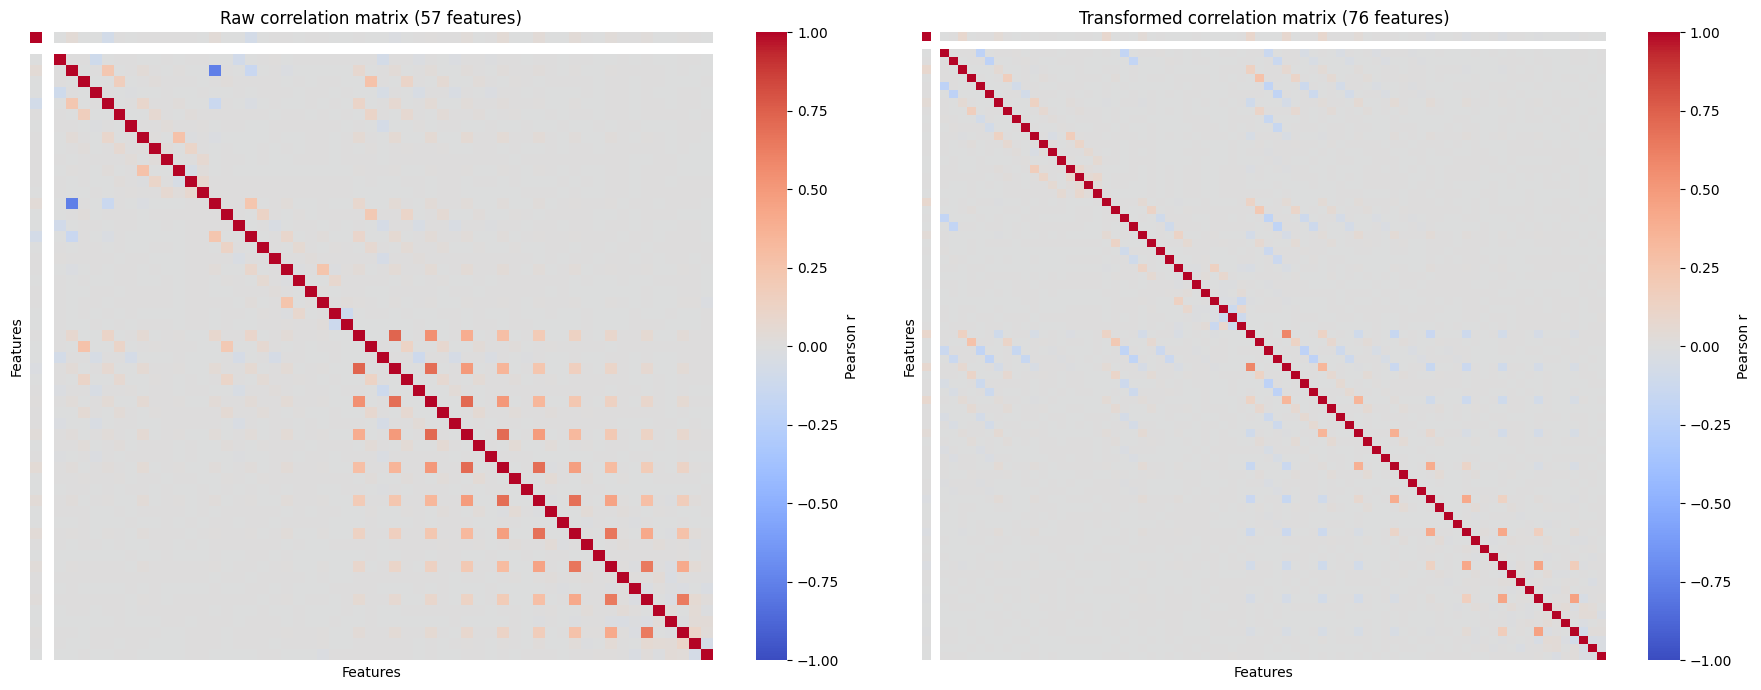

In [6]:
raw_corr = np.corrcoef(X_raw, rowvar=False)
tf_corr = np.corrcoef(X_tf, rowvar=False)

def plot_corr_matrices(mats, titles, figsize=(18, 7), cmap='coolwarm'):
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    if len(mats) == 1:
        axes = [axes]

    for ax, M, title in zip(axes, mats, titles):
        sns.heatmap(
            M,
            ax=ax,
            cmap=cmap,
            center=0.0,
            vmin=-1,
            vmax=1,
            xticklabels=False,
            yticklabels=False,
            cbar_kws={'label': 'Pearson r'}
        )
        ax.set_title(title)
        ax.set_xlabel('Features')
        ax.set_ylabel('Features')

    plt.tight_layout()
    plt.savefig('../report/figures/corr_matrix.png')
    plt.show()

plot_corr_matrices(
    [raw_corr, tf_corr],
    ['Raw correlation matrix (57 features)', 'Transformed correlation matrix (76 features)']
)

del raw_corr, tf_corr

In [7]:
scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw)

pca_raw = PCA().fit(X_raw_scaled)
pca_tf = PCA().fit(X_tf)

raw_curve = np.cumsum(pca_raw.explained_variance_ratio_)
tf_curve = np.cumsum(pca_tf.explained_variance_ratio_)

raw_thresholds = {t: int(np.searchsorted(raw_curve, t) + 1) for t in PCA_TARGET_LEVELS}
tf_thresholds = {t: int(np.searchsorted(tf_curve, t) + 1) for t in PCA_TARGET_LEVELS}

print('PCA comparison')
for t in PCA_TARGET_LEVELS:
    print(f"  {int(t * 100):>2d}% variance -> raw {raw_thresholds[t]:>3d} comps | transformed {tf_thresholds[t]:>3d} comps")

PCA comparison
  90% variance -> raw  44 comps | transformed  18 comps
  95% variance -> raw  48 comps | transformed  22 comps
  99% variance -> raw  54 comps | transformed  33 comps


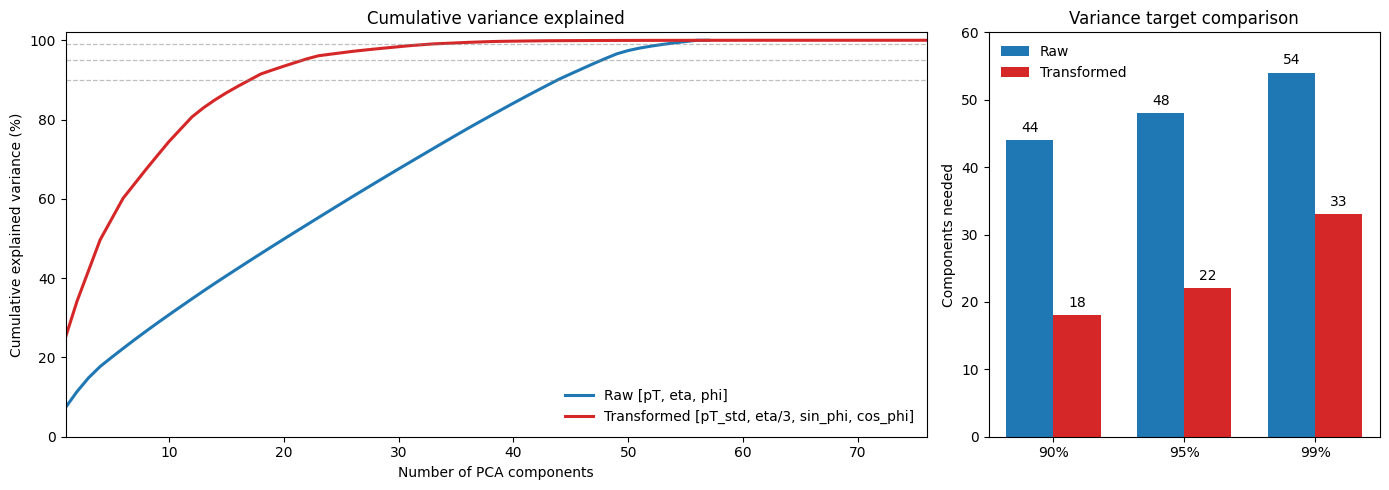

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2.2, 1]})

x_raw = np.arange(1, len(raw_curve) + 1)
x_tf = np.arange(1, len(tf_curve) + 1)

axes[0].plot(x_raw, raw_curve * 100, lw=2.2, color='#1f77b4', label='Raw [pT, eta, phi]')
axes[0].plot(x_tf, tf_curve * 100, lw=2.2, color='#d62728', label='Transformed [pT_std, eta/3, sin_phi, cos_phi]')
for t in PCA_TARGET_LEVELS:
    axes[0].axhline(t * 100, color='gray', ls='--', lw=0.9, alpha=0.5)
axes[0].set_xlabel('Number of PCA components')
axes[0].set_ylabel('Cumulative explained variance (%)')
axes[0].set_title('Cumulative variance explained')
axes[0].set_ylim(0, 102)
axes[0].set_xlim(1, max(len(raw_curve), len(tf_curve)))
axes[0].legend(frameon=False)

threshold_labels = ['90%', '95%', '99%']
raw_vals = [raw_thresholds[t] for t in PCA_TARGET_LEVELS]
tf_vals = [tf_thresholds[t] for t in PCA_TARGET_LEVELS]
bar_x = np.arange(len(threshold_labels))
bar_w = 0.36

axes[1].bar(bar_x - bar_w / 2, raw_vals, width=bar_w, color='#1f77b4', label='Raw')
axes[1].bar(bar_x + bar_w / 2, tf_vals, width=bar_w, color='#d62728', label='Transformed')
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(threshold_labels)
axes[1].set_yticks([0, 10, 20, 30, 40, 50, 60])
axes[1].set_ylabel('Components needed')
axes[1].set_title('Variance target comparison')
axes[1].legend(frameon=False)

for i, (r, t) in enumerate(zip(raw_vals, tf_vals)):
    axes[1].text(i - bar_w / 2, r + 0.8, str(r), ha='center', va='bottom', fontsize=10)
    axes[1].text(i + bar_w / 2, t + 0.8, str(t), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../report/figures/cumulative_variance.png')
plt.show()